# Exploratory Data Analysis (EDA):

1. Load the diabetes dataset using Python's pandas library.

In [2]:
import numpy as np 
import pandas as pd

In [6]:
df=pd.read_csv("diabetes (1).csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [7]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
df.shape

(768, 9)

In [11]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [12]:
print(df.dtypes)

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


2. Check for missing values.

In [13]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

3. Explore data distributions using histograms and box plots.

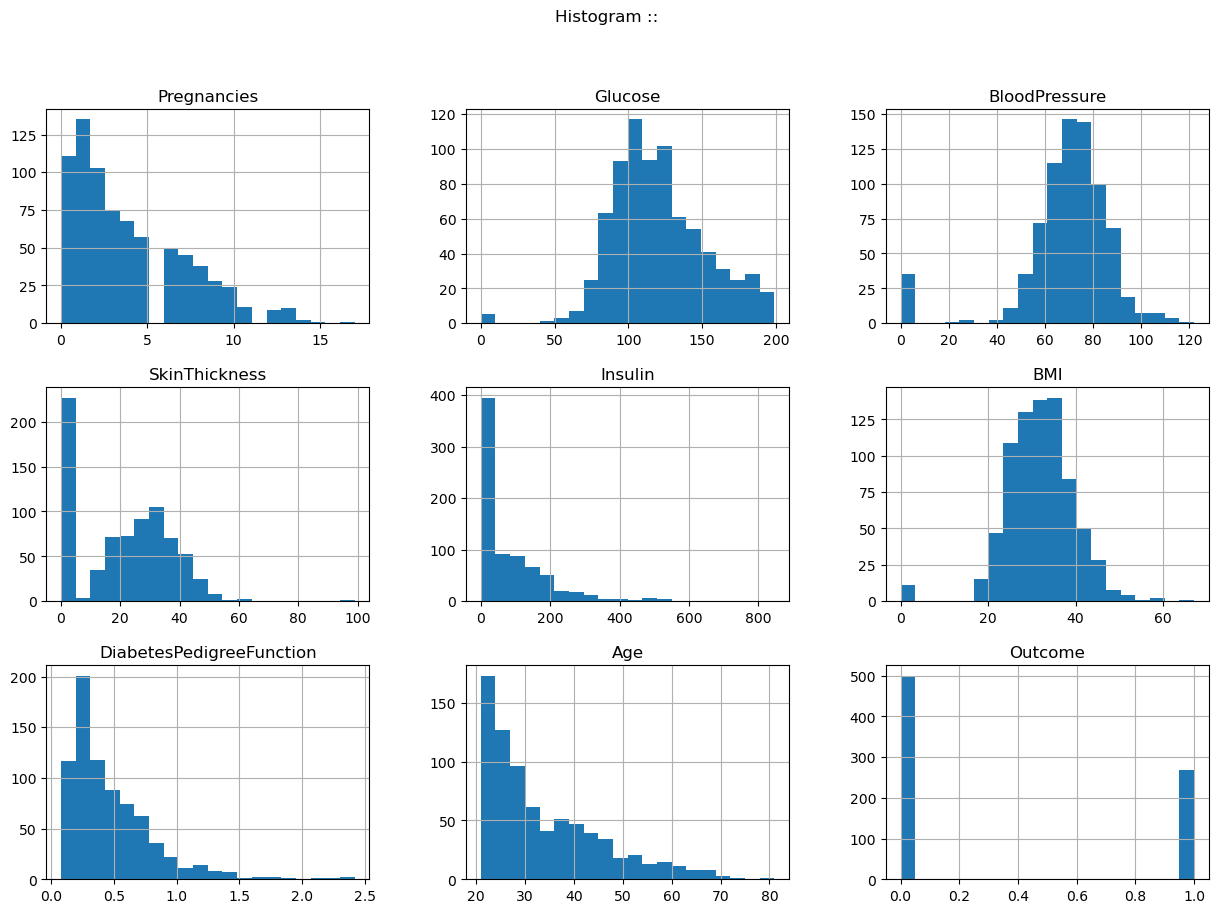

In [19]:
import matplotlib.pyplot as plt

df.hist(figsize=(15,10),bins=20)
plt.suptitle("Histogram :: ")
plt.show()

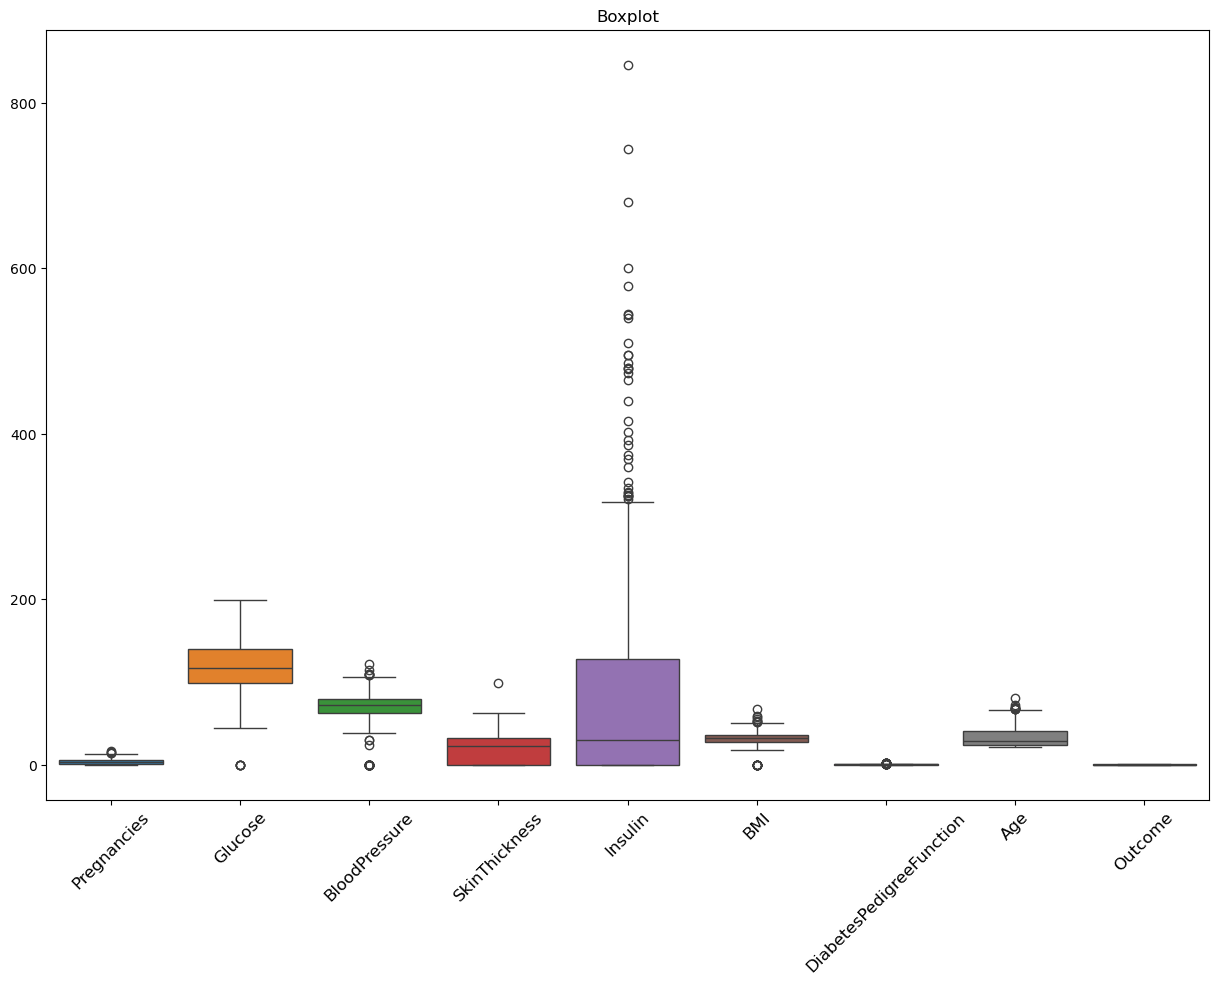

In [25]:
import seaborn as sns 
plt.figure(figsize=(15,10))
sns.boxplot(data=df)
plt.title("Boxplot")
plt.xticks(rotation=45,fontsize=12)
plt.show()

4. Visualize relationships between features and survival using scatter plots and bar plots.

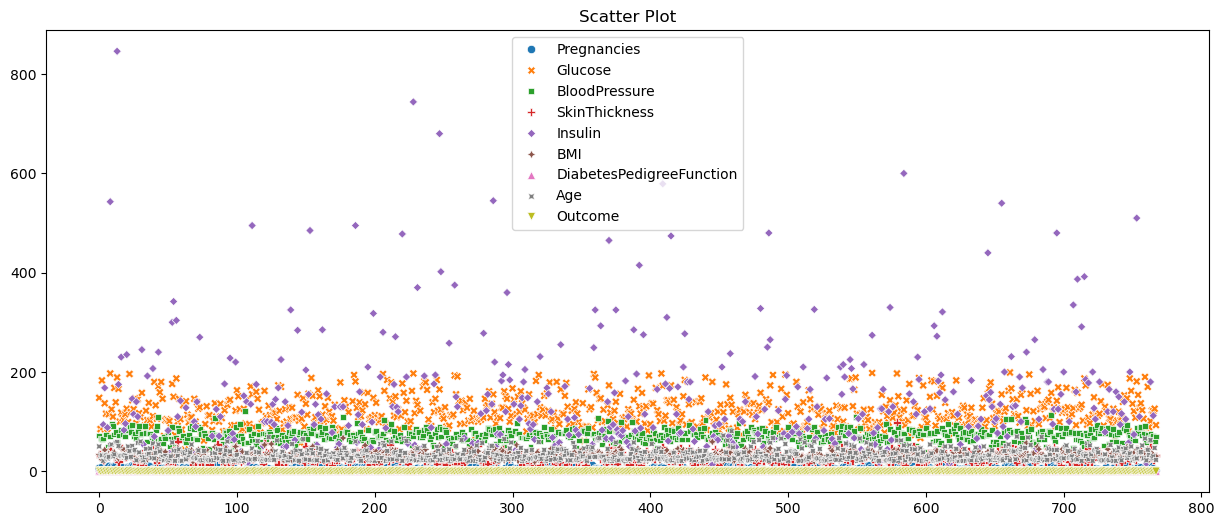

In [29]:
plt.figure(figsize=(15,6))
sns.scatterplot(data=df)
plt.title("Scatter Plot")
plt.show()

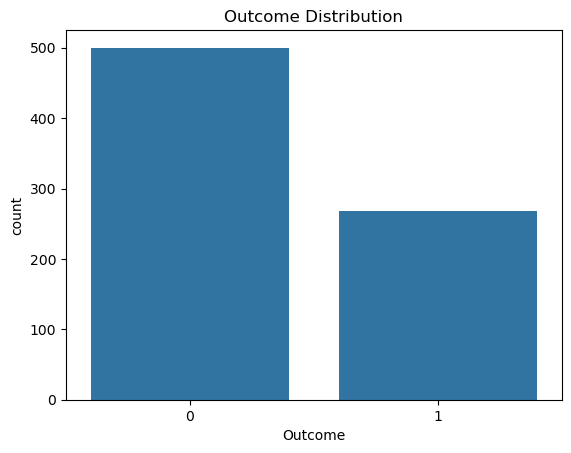

In [30]:
sns.countplot(x='Outcome', data=df)

plt.title("Outcome Distribution")

plt.show()

# Data Preprocessing:

1. Impute missing values.

In [32]:
(df[['Glucose',
     'BloodPressure',
     'SkinThickness',
     'Insulin',
     'BMI']] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [33]:
columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

df[columns] = df[columns].replace(0, np.nan)

In [34]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [35]:
df.fillna(df.mean(), inplace=True)

In [36]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

2. Encode categorical variables using one-hot encoding or label encoding.

3. If needed you can apply more preprocessing methods on the given dataset.

# 3 . Building Predictive Models:

1. Split the preprocessed dataset into training and testing sets.

In [38]:
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]

y = df['Outcome']

In [40]:
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Apply scaling
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# Display first rows
X_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.865108,-0.033518,6.655021e-01,-3.345079e-16,0.166292,0.468492,1.425995
1,-0.844885,-1.206162,-0.529859,-1.746338e-02,-3.345079e-16,-0.852531,-0.365061,-0.190672
2,1.233880,2.015813,-0.695306,8.087936e-16,-3.345079e-16,-1.332833,0.604397,-0.105584
3,-0.844885,-1.074652,-0.529859,-7.004289e-01,-7.243887e-01,-0.634212,-0.920763,-1.041549
4,-1.141852,0.503458,-2.680669,6.655021e-01,1.465506e-01,1.548980,5.484909,-0.020496


In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2,random_state=42)

2. Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.

In [42]:
from sklearn.metrics import (
                                accuracy_score,
                                precision_score,
                                recall_score,
                                f1_score,
                                classification_report,
                                confusion_matrix
                            )

3. Build predictive models using LightGBM and XGBoost algorithms.

In [43]:
!pip install lightgbm
!pip install xgboost

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 185.8 kB/s eta 0:00:05
   -------------- ------------------------- 0.5/1.5 MB 185.8 kB/s eta 0:00:05
   -------------- ------------------------- 0.5/1.5 MB 185.8 kB/s eta 0:00:05
   -------------- ------------------------- 0.5/1.5 MB 185.8 kB/s eta 0:00:05
   -------------- ------------------------- 0.5/1.5 MB 185.8 kB/s e

In [44]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [46]:
lgbm = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=4 )
xgb = XGBClassifier( n_estimators=100, learning_rate=0.1, random_state=42 )

In [47]:
lgbm.fit(X_train, y_train)
xgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [48]:
lgbm_pred = lgbm.predict(X_test)

xgb_pred = xgb.predict(X_test)

In [49]:
lgbm_accuracy = accuracy_score(
    y_test,
    lgbm_pred
)

lgbm_precision = precision_score(
    y_test,
    lgbm_pred
)

lgbm_recall = recall_score(
    y_test,
    lgbm_pred
)

lgbm_f1 = f1_score(
    y_test,
    lgbm_pred
)

print("LightGBM Accuracy:",
      lgbm_accuracy)

print("LightGBM Precision:",
      lgbm_precision)

print("LightGBM Recall:",
      lgbm_recall)

print("LightGBM F1-Score:",
      lgbm_f1)

LightGBM Accuracy: 0.7337662337662337
LightGBM Precision: 0.6129032258064516
LightGBM Recall: 0.6909090909090909
LightGBM F1-Score: 0.6495726495726496


In [50]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

print("XGBoost Accuracy:",
      xgb_accuracy)

print("XGBoost Precision:",
      xgb_precision)

print("XGBoost Recall:",
      xgb_recall)

print("XGBoost F1-Score:",
      xgb_f1)

XGBoost Accuracy: 0.7337662337662337
XGBoost Precision: 0.609375
XGBoost Recall: 0.7090909090909091
XGBoost F1-Score: 0.6554621848739496


In [51]:
print("LightGBM Report")

print(classification_report(
    y_test,
    lgbm_pred
))

print("XGBoost Report")

print(classification_report(
    y_test,
    xgb_pred
))

LightGBM Report
              precision    recall  f1-score   support

           0       0.82      0.76      0.79        99
           1       0.61      0.69      0.65        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.72       154
weighted avg       0.74      0.73      0.74       154

XGBoost Report
              precision    recall  f1-score   support

           0       0.82      0.75      0.78        99
           1       0.61      0.71      0.66        55

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



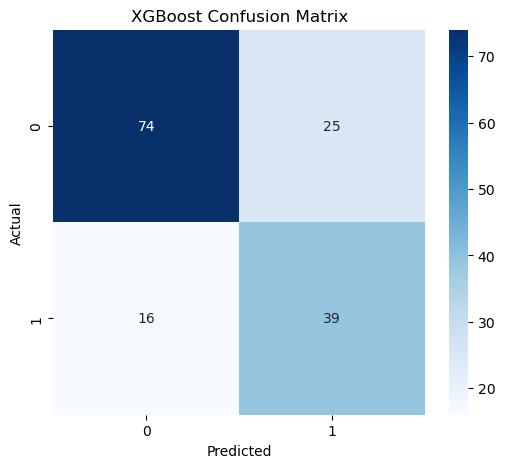

In [52]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

5. Use techniques like cross-validation and hyperparameter tuning to optimize model performance.

In [53]:
from sklearn.model_selection import cross_val_score

In [54]:
lgbm_cv = cross_val_score(
    lgbm,
    X_scaled,
    y,
    cv=5
)

xgb_cv = cross_val_score(
    xgb,
    X_scaled,
    y,
    cv=5
)

print("LightGBM CV Score:",
      lgbm_cv.mean())

print("XGBoost CV Score:",
      xgb_cv.mean())

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000326 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 670
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [55]:
from sklearn.model_selection import GridSearchCV

In [56]:
params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1]
}

In [57]:
grid = GridSearchCV(
    LGBMClassifier(),
    params,
    cv=3
)

grid.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 142, number of negative: 267
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000183 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 514
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.347188 -> initscore=-0.631422
[LightGBM] [Info] Start training from score -0.631422
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,estimator,LGBMClassifier()
,param_grid,"{'learning_rate': [0.01, 0.1], 'n_estimators': [50, 100]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [58]:
print(grid.best_params_)

{'learning_rate': 0.1, 'n_estimators': 50}


# 4. Comparative Analysis:

1. Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.

In [59]:
results = pd.DataFrame({
    'Model': ['LightGBM',
              'XGBoost'],
    
    'Accuracy': [
        lgbm_accuracy,
        xgb_accuracy
    ],
    
    'Precision': [
        lgbm_precision,
        xgb_precision
    ],
    
    'Recall': [
        lgbm_recall,
        xgb_recall
    ],
    
    'F1-Score': [
        lgbm_f1,
        xgb_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,LightGBM,0.733766,0.612903,0.690909,0.649573
1,XGBoost,0.733766,0.609375,0.709091,0.655462


In [68]:
print("Accuracy: {:.2f}%".format(lgbm_accuracy * 100))
print("Precision: {:.2f}%".format(lgbm_precision * 100))
print("Recall: {:.2f}%".format(lgbm_recall * 100))
print("F1-Score: {:.2f}%".format(lgbm_f1 * 100))

Accuracy: 73.38%
Precision: 61.29%
Recall: 69.09%
F1-Score: 64.96%


In [69]:
print("Accuracy: {:.2f}%".format(xgb_accuracy * 100))
print("Precision: {:.2f}%".format(xgb_precision * 100))
print("Recall: {:.2f}%".format(xgb_recall * 100))
print("F1-Score: {:.2f}%".format(xgb_f1 * 100))

Accuracy: 73.38%
Precision: 60.94%
Recall: 70.91%
F1-Score: 65.55%


2. Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.

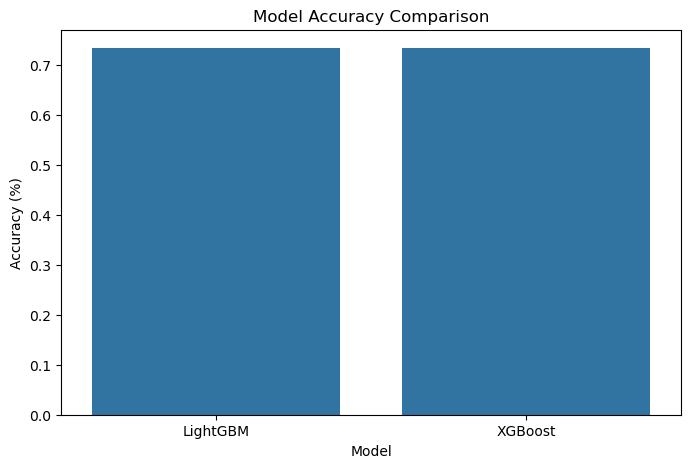

In [70]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.show()

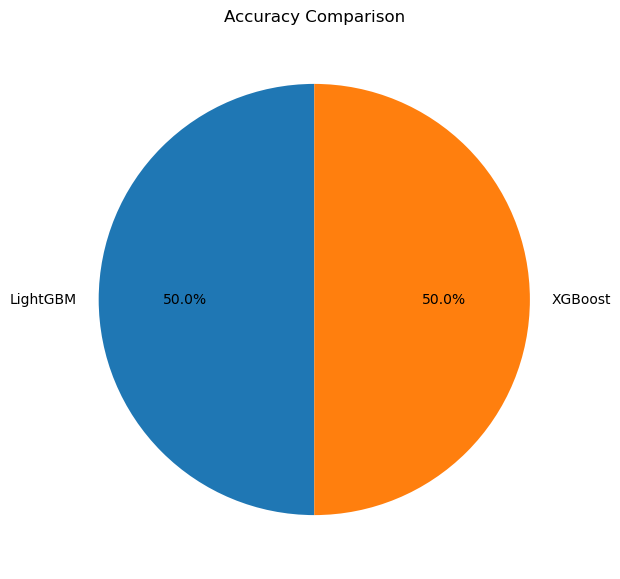

In [71]:
models = ['LightGBM',
          'XGBoost']

accuracies = [
    lgbm_accuracy * 100,
    xgb_accuracy * 100
]

plt.figure(figsize=(7,7))

plt.pie(
    accuracies,
    labels=models,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Accuracy Comparison")

plt.show()

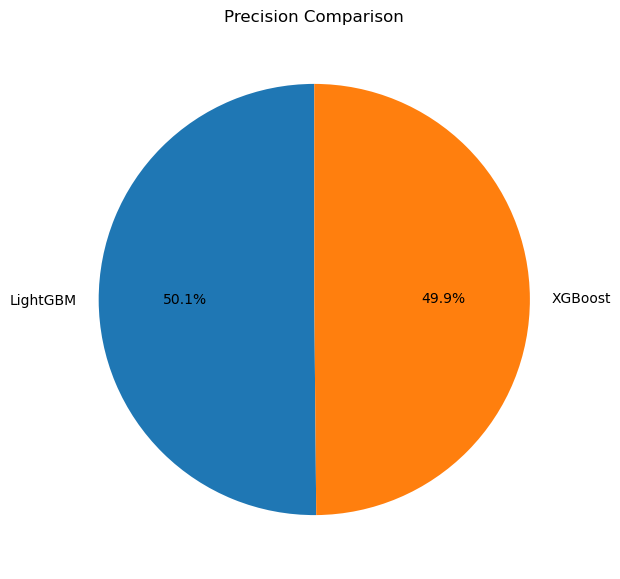

In [72]:
models = ['LightGBM',
          'XGBoost']

accuracies = [ 
    lgbm_precision * 100,
    xgb_precision * 100
]

plt.figure(figsize=(7,7))

plt.pie(
    accuracies,
    labels=models,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Precision Comparison")

plt.show()

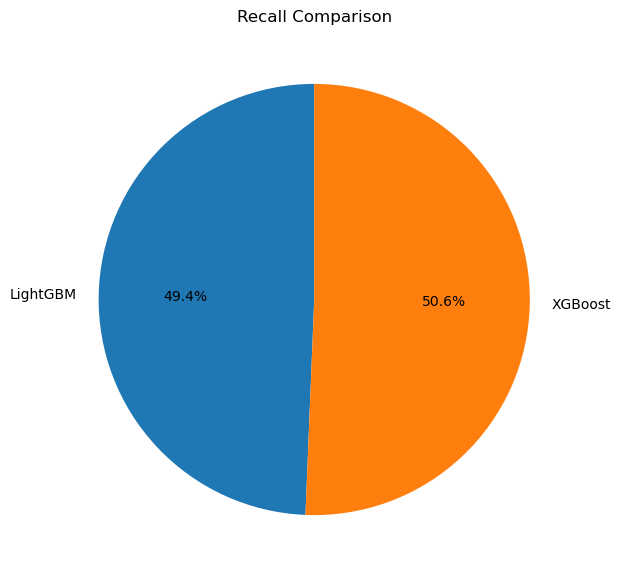

In [73]:
models = ['LightGBM',
          'XGBoost']

accuracies = [ 
    lgbm_recall * 100,
    xgb_recall * 100
]

plt.figure(figsize=(7,7))

plt.pie(
    accuracies,
    labels=models,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Recall Comparison")

plt.show()

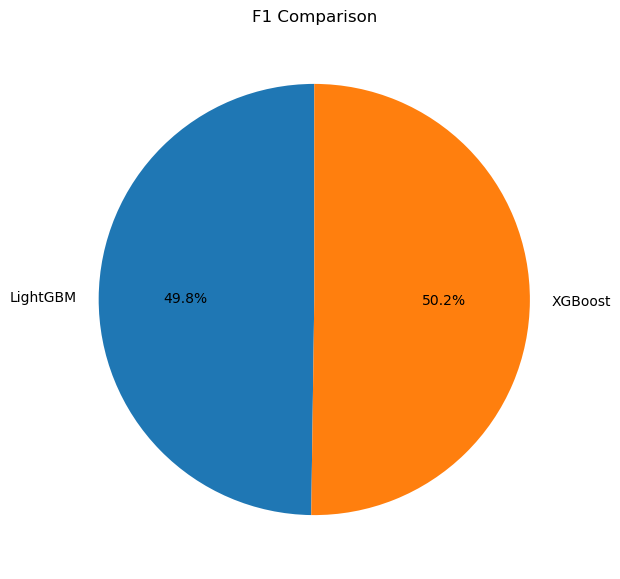

In [74]:
models = ['LightGBM',
          'XGBoost']

accuracies = [ 
    lgbm_f1 * 100,
    xgb_f1 * 100
]

plt.figure(figsize=(7,7))

plt.pie(
    accuracies,
    labels=models,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("F1 Comparison")

plt.show()

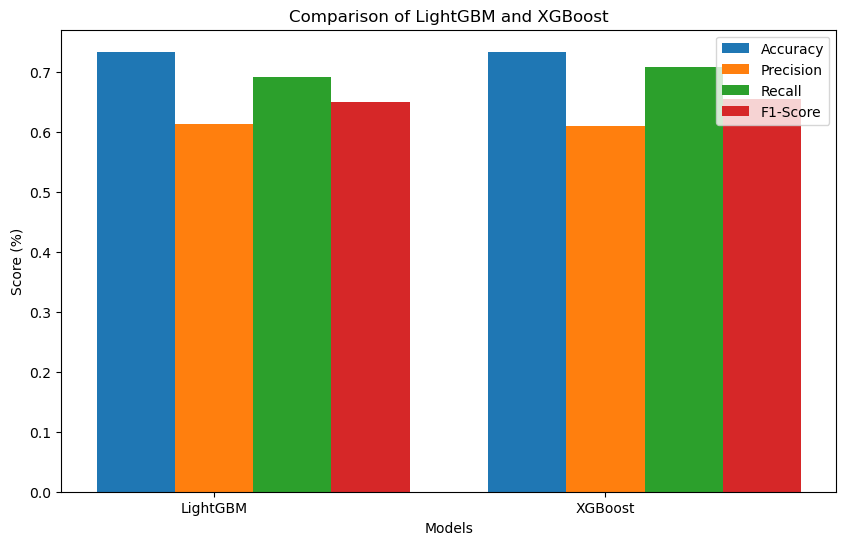

In [75]:
# Set figure size
plt.figure(figsize=(10,6))

# Set bar width
bar_width = 0.2

# X-axis positions
x = np.arange(len(results['Model']))

# Plot bars
plt.bar(
    x,
    results['Accuracy'],
    width=bar_width,
    label='Accuracy'
)

plt.bar(
    x + bar_width,
    results['Precision'],
    width=bar_width,
    label='Precision'
)

plt.bar(
    x + 2*bar_width,
    results['Recall'],
    width=bar_width,
    label='Recall'
)

plt.bar(
    x + 3*bar_width,
    results['F1-Score'],
    width=bar_width,
    label='F1-Score'
)

# Labels and Titles
plt.xlabel("Models")

plt.ylabel("Score (%)")

plt.title("Comparison of LightGBM and XGBoost")

plt.xticks(
    x + bar_width,
    results['Model']
)

plt.legend()

plt.show()